# Functional Time and Recoverability Window — Minimal ERC Model

## Final reproducible notebook

This notebook explores whether recoverability depends not only on total perturbation load, but on the relation between:

- perturbation delivery timescale
- internal recovery timescale
- available functional recovery window

Core working hypothesis:

> Functional time may collapse before state-space collapse.

The notebook generates deterministic, history-dependent, stochastic, and numerical-sensitivity outputs for a minimal Endogenous Recoverability Collapse (ERC) model.

# Notebook structure

1. Setup and reproducibility paths  
2. Global parameters  
3. Minimal recoverability model  
4. Deterministic examples  
5. Parameter sweep and recoverability boundary  
6. Functional time landscape  
7. Temporal accessibility ratio  
8. Robustness tests  
9. History-dependent recoverability  
10. Stochastic robustness  
11. Numerical sensitivity  
12. Final summary, outputs, and ZIP archive

# 1. Setup and reproducibility paths

By default, this notebook saves outputs into a local project folder.

If running in Google Colab and you want persistent Drive storage, set:

```python
USE_GOOGLE_DRIVE = True
```

inside the setup cell.

In [1]:
# ============================================================
# 1. SETUP
# ============================================================

import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Optional: set True when running in Google Colab and saving to Drive
USE_GOOGLE_DRIVE = False

PROJECT_NAME = "functional_time_erc_model"

if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_ROOT = "/content/drive/MyDrive/ERC_projects"
    PROJECT_PATH = os.path.join(DRIVE_ROOT, PROJECT_NAME)
else:
    PROJECT_PATH = PROJECT_NAME

for folder in [
    PROJECT_PATH,
    f"{PROJECT_PATH}/figures",
    f"{PROJECT_PATH}/tables",
    f"{PROJECT_PATH}/outputs",
]:
    os.makedirs(folder, exist_ok=True)

print("Project path:")
print(PROJECT_PATH)

Project path:
functional_time_erc_model


# 2. Global parameters

The model uses a minimal finite-time recovery system.

Main control variables:

- `AUC`: total perturbation load
- `sigma`: perturbation delivery timescale
- `tau_r`: internal recovery timescale
- `T_WINDOW`: available functional recovery window
- `RECOVERY_THRESHOLD`: operational criterion for recovery

In [2]:
# ============================================================
# 2. GLOBAL PARAMETERS
# ============================================================

AUC = 1.0
T_MAX = 80
DT = 0.05
T_WINDOW = 50

x0 = 0.0
RECOVERY_THRESHOLD = 0.05
PERTURBATION_CENTER = 10

sigma_values = np.linspace(0.5, 12, 50)
tau_r_values = np.linspace(1, 25, 50)

t_eval = np.arange(0, T_MAX, DT)

np.random.seed(42)

print("Global parameters initialized.")
print(f"AUC = {AUC}")
print(f"T_MAX = {T_MAX}")
print(f"DT = {DT}")
print(f"T_WINDOW = {T_WINDOW}")
print(f"RECOVERY_THRESHOLD = {RECOVERY_THRESHOLD}")

Global parameters initialized.
AUC = 1.0
T_MAX = 80
DT = 0.05
T_WINDOW = 50
RECOVERY_THRESHOLD = 0.05


# 3. Minimal recoverability model

We define a minimal rate-limited recovery system subjected to transient Gaussian forcing:

\[
\frac{dx}{dt} = -\frac{x}{\tau_r} + u(t)
\]

where:

- \(x(t)\) is system deviation from baseline
- \(\tau_r\) is internal recovery timescale
- \(u(t)\) is a Gaussian perturbation normalized by total load AUC
- \(\sigma\) controls perturbation delivery timescale

The key outcome is not simply whether the system evolves, but whether it returns within the available functional time window.

In [3]:
# ============================================================
# 3. MODEL FUNCTIONS
# ============================================================

def gaussian_input(t, auc=AUC, sigma=2.0, center=PERTURBATION_CENTER):
    """
    Gaussian perturbation normalized so total area approximates AUC.
    Smaller sigma = faster/sharper perturbation.
    Larger sigma = slower/broader perturbation.
    """
    amplitude = auc / (sigma * np.sqrt(2 * np.pi))
    return amplitude * np.exp(-0.5 * ((t - center) / sigma) ** 2)


def erc_time_system(t, x, tau_r, sigma, auc=AUC):
    """
    Minimal recovery system:
    dx/dt = -x/tau_r + u(t)
    """
    u = gaussian_input(t, auc=auc, sigma=sigma)
    dxdt = -x[0] / tau_r + u
    return [dxdt]


def simulate_trajectory(tau_r, sigma, auc=AUC, t_max=T_MAX, dt=DT):
    """
    Deterministic trajectory simulation.
    """
    local_t_eval = np.arange(0, t_max, dt)

    sol = solve_ivp(
        fun=lambda t, x: erc_time_system(t, x, tau_r=tau_r, sigma=sigma, auc=auc),
        t_span=(0, t_max),
        y0=[x0],
        t_eval=local_t_eval,
        rtol=1e-8,
        atol=1e-10
    )

    x = sol.y[0]
    u = gaussian_input(local_t_eval, auc=auc, sigma=sigma)

    return local_t_eval, x, u


def compute_recovery_metrics(
    t,
    x,
    t_window=T_WINDOW,
    recovery_threshold=RECOVERY_THRESHOLD,
    peak_time=PERTURBATION_CENTER
):
    """
    Recovery is measured after the perturbation peak.
    The system is considered recovered when x returns below threshold.
    """
    after_peak = t > peak_time
    t_after = t[after_peak]
    x_after = x[after_peak]

    recovered_indices = np.where(x_after <= recovery_threshold)[0]

    if len(recovered_indices) == 0:
        recovered = False
        t_return = np.nan
        functional_time = -np.inf
    else:
        recovered = True
        t_return = t_after[recovered_indices[0]]
        functional_time = t_window - t_return

    recovered_within_window = recovered and (t_return <= t_window)

    return {
        "recovered": recovered,
        "recovered_within_window": recovered_within_window,
        "t_return": t_return,
        "functional_time": functional_time,
        "x_max": np.max(x)
    }

# 4. Deterministic trajectory examples

We first compare trajectories with the same total input but different perturbation and recovery timescales.

This illustrates the central distinction:

> identical external simulation time does not imply identical functional recovery time.

Fast input / fast recovery
{'recovered': True, 'recovered_within_window': np.True_, 't_return': np.float64(19.200000000000003), 'functional_time': np.float64(30.799999999999997), 'x_max': np.float64(0.571807185620638)}
------------------------------------------------------------
Fast input / slow recovery
{'recovered': True, 'recovered_within_window': np.True_, 't_return': np.float64(46.0), 'functional_time': np.float64(4.0), 'x_max': np.float64(0.8268740267981919)}
------------------------------------------------------------
Slow input / slow recovery
{'recovered': True, 'recovered_within_window': np.True_, 't_return': np.float64(48.300000000000004), 'functional_time': np.float64(1.6999999999999957), 'x_max': np.float64(0.38710724335824975)}
------------------------------------------------------------


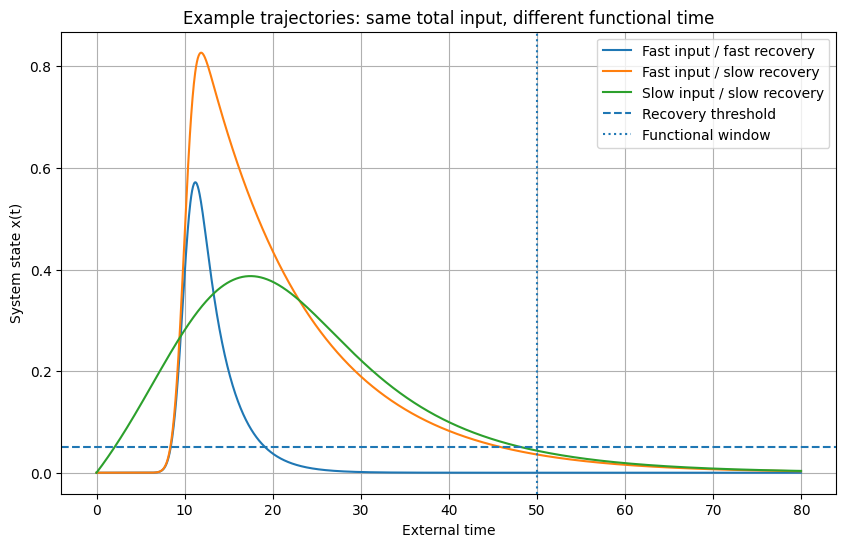

In [4]:
# ============================================================
# 4. DETERMINISTIC EXAMPLES
# ============================================================

test_cases = [
    {"label": "Fast input / fast recovery", "sigma": 1.0, "tau_r": 3.0},
    {"label": "Fast input / slow recovery", "sigma": 1.0, "tau_r": 12.0},
    {"label": "Slow input / slow recovery", "sigma": 8.0, "tau_r": 12.0},
]

for case in test_cases:
    t, x, u = simulate_trajectory(tau_r=case["tau_r"], sigma=case["sigma"])
    metrics = compute_recovery_metrics(t, x)
    print(case["label"])
    print(metrics)
    print("-" * 60)

plt.figure(figsize=(10, 6))

for case in test_cases:
    t, x, u = simulate_trajectory(tau_r=case["tau_r"], sigma=case["sigma"])
    plt.plot(t, x, label=case["label"])

plt.axhline(RECOVERY_THRESHOLD, linestyle="--", label="Recovery threshold")
plt.axvline(T_WINDOW, linestyle=":", label="Functional window")
plt.xlabel("External time")
plt.ylabel("System state x(t)")
plt.title("Example trajectories: same total input, different functional time")
plt.legend()
plt.grid(True)

plt.savefig(f"{PROJECT_PATH}/figures/example_deterministic_trajectories.png", dpi=300, bbox_inches="tight")
plt.show()

## Interpretation

The example trajectories show that recovery is not determined by total input alone.

The same system can remain dynamically defined while losing the ability to return within the available operational window.

# 5. Deterministic parameter sweep and recoverability boundary

We sweep over:

- perturbation timescale \(\sigma\)
- internal recovery timescale \(\tau_r\)

and classify whether each trajectory recovers within the functional window.

In [5]:
# ============================================================
# 5. DETERMINISTIC SWEEP
# ============================================================

results = []

for sigma in sigma_values:
    for tau_r in tau_r_values:
        t, x, u = simulate_trajectory(tau_r=tau_r, sigma=sigma)
        metrics = compute_recovery_metrics(t, x)

        results.append({
            "sigma": sigma,
            "tau_r": tau_r,
            "recovered": metrics["recovered"],
            "recovered_within_window": metrics["recovered_within_window"],
            "t_return": metrics["t_return"],
            "functional_time": metrics["functional_time"],
            "x_max": metrics["x_max"],
            "tau_sigma_ratio": tau_r / sigma,
            "sigma_tau_ratio": sigma / tau_r
        })

df = pd.DataFrame(results)

df["functional_time_clean"] = df["functional_time"].replace(-np.inf, np.nan)
df["temporal_margin"] = T_WINDOW - df["t_return"]
df["temporal_status"] = np.where(
    df["recovered_within_window"],
    "ACCESSIBLE",
    "TIME_COLLAPSED"
)

df.head()

,sigma,tau_r,recovered,recovered_within_window,t_return,functional_time,x_max,tau_sigma_ratio,sigma_tau_ratio,functional_time_clean,temporal_margin,temporal_status
0,0.5,1.000000,True,True,13.15,36.85,0.475235,2.000000,0.500000,36.85,36.85,ACCESSIBLE
1,0.5,1.489796,True,True,14.55,35.45,0.570236,2.979592,0.335616,35.45,35.45,ACCESSIBLE
2,0.5,1.979592,True,True,16.00,34.00,0.633857,3.959184,0.252577,34.00,34.00,ACCESSIBLE
3,0.5,2.469388,True,True,17.45,32.55,0.680108,4.938776,0.202479,32.55,32.55,ACCESSIBLE
4,0.5,2.959184,True,True,18.95,31.05,0.715172,5.918367,0.168966,31.05,31.05,ACCESSIBLE


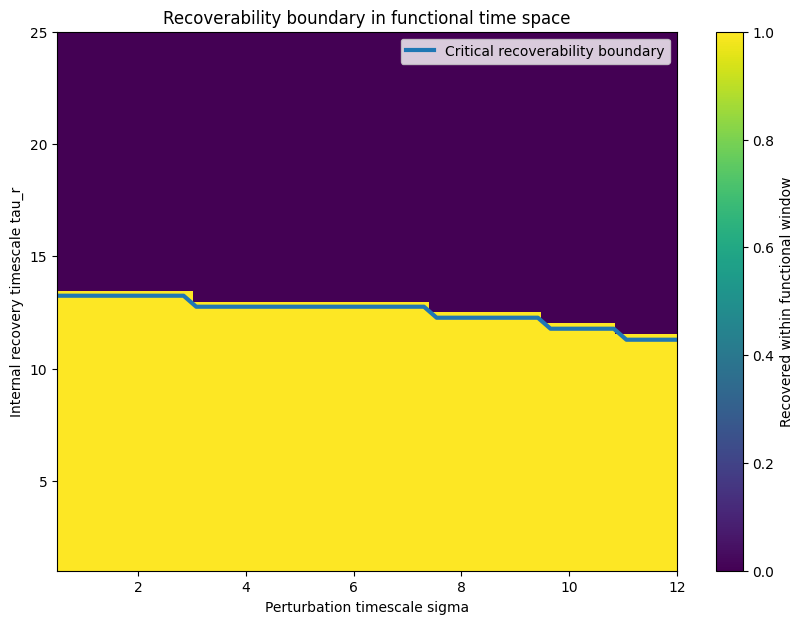

In [6]:
# ============================================================
# 5B. BOUNDARY DETECTION
# ============================================================

boundary_points = []

for sigma in sigma_values:
    df_sigma = df[df["sigma"] == sigma].sort_values("tau_r")
    accessible = df_sigma[df_sigma["recovered_within_window"] == True]

    if len(accessible) > 0:
        tau_critical = accessible["tau_r"].max()
        boundary_points.append({
            "sigma": sigma,
            "tau_r_critical": tau_critical
        })

boundary_df = pd.DataFrame(boundary_points)

pivot_recovery = df.pivot(
    index="tau_r",
    columns="sigma",
    values="recovered_within_window"
)

plt.figure(figsize=(10, 7))
plt.imshow(
    pivot_recovery,
    origin="lower",
    aspect="auto",
    extent=[sigma_values.min(), sigma_values.max(), tau_r_values.min(), tau_r_values.max()]
)

plt.plot(
    boundary_df["sigma"],
    boundary_df["tau_r_critical"],
    linewidth=3,
    label="Critical recoverability boundary"
)

plt.colorbar(label="Recovered within functional window")
plt.xlabel("Perturbation timescale sigma")
plt.ylabel("Internal recovery timescale tau_r")
plt.title("Recoverability boundary in functional time space")
plt.legend()

plt.savefig(f"{PROJECT_PATH}/figures/recoverability_boundary_map.png", dpi=300, bbox_inches="tight")
plt.show()

## Interpretation

A recoverability boundary emerges in the space defined by perturbation timescale and internal recovery timescale.

This boundary does not represent disappearance of the state space. It represents loss of operational accessibility within the available functional window.

# 6. Functional time landscape

We now move from a binary classification to a continuous measure:

\[
T_{functional} = T_{window} - T_{return}
\]

Positive values indicate remaining functional recovery time.  
Negative values indicate delayed recovery beyond the available window.

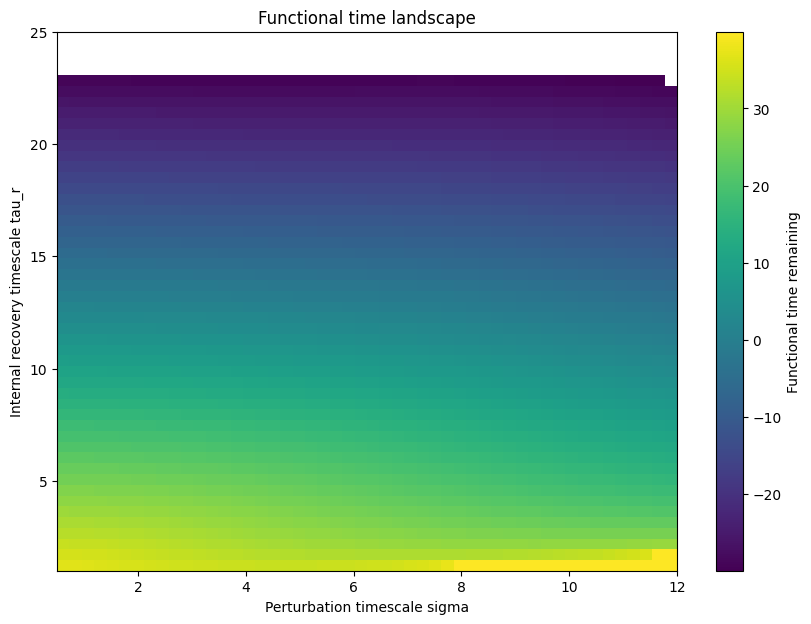

In [7]:
# ============================================================
# 6. FUNCTIONAL TIME LANDSCAPE
# ============================================================

pivot_functional_time = df.pivot(
    index="tau_r",
    columns="sigma",
    values="functional_time_clean"
)

plt.figure(figsize=(10, 7))
plt.imshow(
    pivot_functional_time,
    origin="lower",
    aspect="auto",
    extent=[sigma_values.min(), sigma_values.max(), tau_r_values.min(), tau_r_values.max()]
)

plt.colorbar(label="Functional time remaining")
plt.xlabel("Perturbation timescale sigma")
plt.ylabel("Internal recovery timescale tau_r")
plt.title("Functional time landscape")

plt.savefig(f"{PROJECT_PATH}/figures/functional_time_landscape.png", dpi=300, bbox_inches="tight")
plt.show()

## Interpretation

The functional time landscape shows a gradual erosion of temporal accessibility rather than a purely binary transition.

This suggests that recoverability may degrade continuously before outright non-return.

# 7. Temporal accessibility ratio

We test whether the transition is organized by the effective dimensionless ratio:

\[
\frac{\tau_r}{\sigma}
\]

where:

- \(\tau_r\) = internal recovery timescale
- \(\sigma\) = perturbation delivery timescale

This ratio compares how quickly the system can recover relative to how quickly the perturbation is delivered.

,ratio_bin,mean_ratio,median_ratio,mean_functional_time,median_functional_time,accessible_fraction,count
0,"(0.0823, 0.292]",0.192871,0.195565,31.727391,31.50,1.000000,115
1,"(0.292, 0.477]",0.384783,0.384071,24.237391,23.75,1.000000,115
2,"(0.477, 0.659]",0.568139,0.569554,20.219130,19.25,1.000000,115
3,"(0.659, 0.834]",0.749964,0.750865,17.087391,15.65,1.000000,115
4,"(0.834, 1.022]",0.931019,0.931734,12.367391,10.85,0.973913,115


,corr_tau_r_functional_time,corr_sigma_functional_time,corr_tau_sigma_ratio_functional_time,corr_sigma_tau_ratio_functional_time
0,-0.994274,-0.076806,-0.338141,0.562937


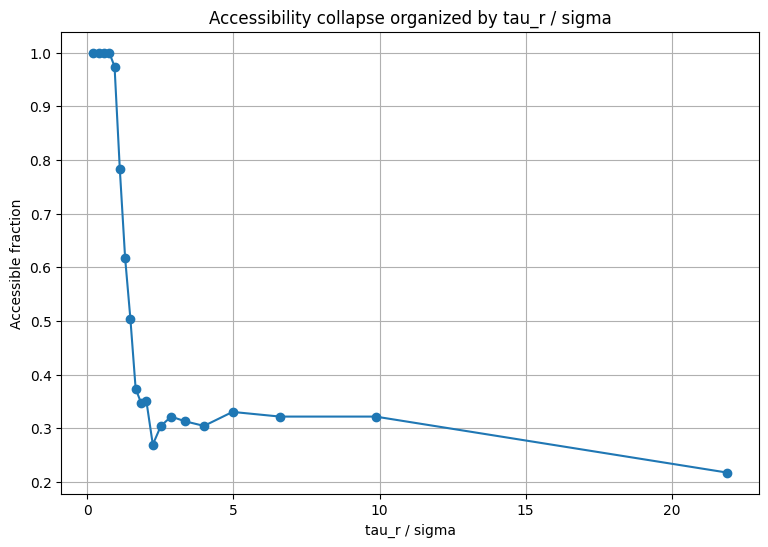

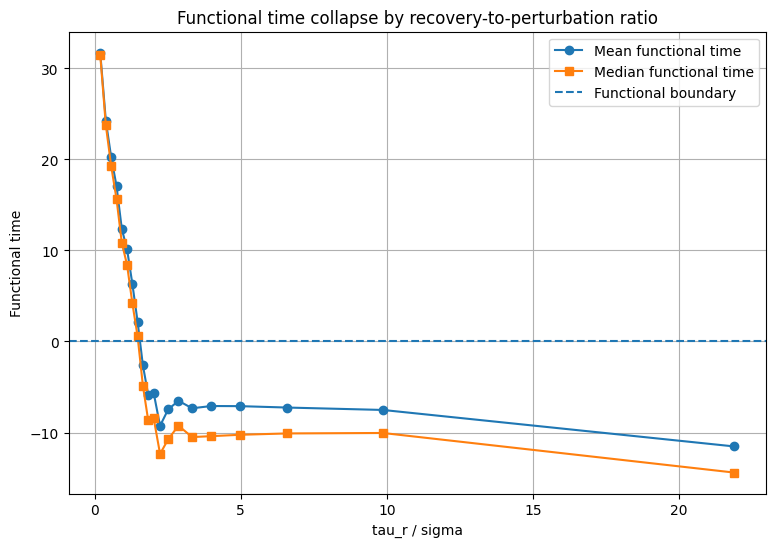

In [8]:
# ============================================================
# 7. RATIO ANALYSIS
# ============================================================

ratio_df = df.dropna(subset=["tau_sigma_ratio", "functional_time_clean"]).copy()

ratio_df["ratio_bin"] = pd.qcut(
    ratio_df["tau_sigma_ratio"],
    q=20,
    duplicates="drop"
)

ratio_summary = ratio_df.groupby("ratio_bin", observed=False).agg(
    mean_ratio=("tau_sigma_ratio", "mean"),
    median_ratio=("tau_sigma_ratio", "median"),
    mean_functional_time=("functional_time_clean", "mean"),
    median_functional_time=("functional_time_clean", "median"),
    accessible_fraction=("recovered_within_window", "mean"),
    count=("functional_time_clean", "count")
).reset_index()

correlations = {
    "corr_tau_r_functional_time": ratio_df["tau_r"].corr(ratio_df["functional_time_clean"]),
    "corr_sigma_functional_time": ratio_df["sigma"].corr(ratio_df["functional_time_clean"]),
    "corr_tau_sigma_ratio_functional_time": ratio_df["tau_sigma_ratio"].corr(ratio_df["functional_time_clean"]),
    "corr_sigma_tau_ratio_functional_time": ratio_df["sigma_tau_ratio"].corr(ratio_df["functional_time_clean"]),
}

correlations_df = pd.DataFrame([correlations])

display(ratio_summary.head())
display(correlations_df)

plt.figure(figsize=(9, 6))
plt.plot(
    ratio_summary["mean_ratio"],
    ratio_summary["accessible_fraction"],
    marker="o"
)
plt.xlabel("tau_r / sigma")
plt.ylabel("Accessible fraction")
plt.title("Accessibility collapse organized by tau_r / sigma")
plt.grid(True)

plt.savefig(f"{PROJECT_PATH}/figures/accessibility_vs_tau_sigma_ratio_binned.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 6))
plt.plot(
    ratio_summary["mean_ratio"],
    ratio_summary["mean_functional_time"],
    marker="o",
    label="Mean functional time"
)
plt.plot(
    ratio_summary["mean_ratio"],
    ratio_summary["median_functional_time"],
    marker="s",
    label="Median functional time"
)
plt.axhline(0, linestyle="--", label="Functional boundary")
plt.xlabel("tau_r / sigma")
plt.ylabel("Functional time")
plt.title("Functional time collapse by recovery-to-perturbation ratio")
plt.legend()
plt.grid(True)

plt.savefig(f"{PROJECT_PATH}/figures/functional_time_vs_tau_sigma_ratio_binned.png", dpi=300, bbox_inches="tight")
plt.show()

## Interpretation

The results suggest that \(\tau_r / \sigma\) organizes the transition from accessible to collapsed functional time.

This indicates that recoverability is not determined by external time alone, but by the relation between perturbation delivery and internal recovery capacity.

# 8. Robustness tests

We test whether the observed structure persists when changing:

1. available functional window  
2. total perturbation load  
3. recovery threshold  

The purpose is to check whether the boundary is robust or an artifact of a single parameter choice.

In [9]:
# ============================================================
# 8. ROBUSTNESS SWEEP FUNCTION
# ============================================================

def run_functional_time_sweep(
    auc=1.0,
    t_window=50,
    recovery_threshold=0.05,
    sigma_values=None,
    tau_r_values=None,
    t_max=80,
    dt=0.05
):
    """
    Runs a full functional-time ERC sweep for a given parameter set.
    """
    if sigma_values is None:
        sigma_values = np.linspace(0.5, 12, 50)
    if tau_r_values is None:
        tau_r_values = np.linspace(1, 25, 50)

    local_t_eval = np.arange(0, t_max, dt)
    results = []

    for sigma in sigma_values:
        for tau_r in tau_r_values:
            sol = solve_ivp(
                fun=lambda t, x: [
                    -x[0] / tau_r + gaussian_input(
                        t,
                        auc=auc,
                        sigma=sigma,
                        center=PERTURBATION_CENTER
                    )
                ],
                t_span=(0, t_max),
                y0=[x0],
                t_eval=local_t_eval,
                rtol=1e-8,
                atol=1e-10
            )

            t = local_t_eval
            x = sol.y[0]

            metrics = compute_recovery_metrics(
                t,
                x,
                t_window=t_window,
                recovery_threshold=recovery_threshold
            )

            results.append({
                "auc": auc,
                "t_window": t_window,
                "recovery_threshold": recovery_threshold,
                "sigma": sigma,
                "tau_r": tau_r,
                "recovered": metrics["recovered"],
                "recovered_within_window": metrics["recovered_within_window"],
                "t_return": metrics["t_return"],
                "functional_time": metrics["functional_time"],
                "x_max": metrics["x_max"],
                "tau_sigma_ratio": tau_r / sigma,
                "sigma_tau_ratio": sigma / tau_r
            })

    return pd.DataFrame(results)

In [10]:
# ============================================================
# 8B. ROBUSTNESS TESTS
# ============================================================

# Functional window robustness
window_values = [35, 40, 45, 50, 55, 60, 65]
window_robustness = []

for window in window_values:
    temp_df = run_functional_time_sweep(
        auc=AUC,
        t_window=window,
        recovery_threshold=RECOVERY_THRESHOLD,
        sigma_values=sigma_values,
        tau_r_values=tau_r_values
    )

    accessible_fraction = temp_df["recovered_within_window"].mean()
    mean_functional_time = np.nanmean(temp_df["functional_time"].replace(-np.inf, np.nan))

    window_robustness.append({
        "t_window": window,
        "accessible_fraction": accessible_fraction,
        "mean_functional_time": mean_functional_time
    })

window_robustness_df = pd.DataFrame(window_robustness)


# AUC robustness
auc_values = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]
auc_robustness = []

for auc in auc_values:
    temp_df = run_functional_time_sweep(
        auc=auc,
        t_window=T_WINDOW,
        recovery_threshold=RECOVERY_THRESHOLD,
        sigma_values=sigma_values,
        tau_r_values=tau_r_values
    )

    accessible_fraction = temp_df["recovered_within_window"].mean()
    mean_x_max = temp_df["x_max"].mean()
    mean_functional_time = np.nanmean(temp_df["functional_time"].replace(-np.inf, np.nan))

    auc_robustness.append({
        "auc": auc,
        "accessible_fraction": accessible_fraction,
        "mean_x_max": mean_x_max,
        "mean_functional_time": mean_functional_time
    })

auc_robustness_df = pd.DataFrame(auc_robustness)


# Recovery threshold robustness
threshold_values = [0.02, 0.03, 0.05, 0.075, 0.10]
threshold_robustness = []

for threshold in threshold_values:
    temp_df = run_functional_time_sweep(
        auc=AUC,
        t_window=T_WINDOW,
        recovery_threshold=threshold,
        sigma_values=sigma_values,
        tau_r_values=tau_r_values
    )

    accessible_fraction = temp_df["recovered_within_window"].mean()
    mean_functional_time = np.nanmean(temp_df["functional_time"].replace(-np.inf, np.nan))

    threshold_robustness.append({
        "recovery_threshold": threshold,
        "accessible_fraction": accessible_fraction,
        "mean_functional_time": mean_functional_time
    })

threshold_robustness_df = pd.DataFrame(threshold_robustness)

display(window_robustness_df)
display(auc_robustness_df)
display(threshold_robustness_df)

,t_window,accessible_fraction,mean_functional_time
0,35,0.2624,-13.043388
1,40,0.3404,-8.043388
2,45,0.4148,-3.043388
3,50,0.4900,1.956612
4,55,0.5632,6.956612
5,60,0.6336,11.956612
6,65,0.7084,16.956612


,auc,accessible_fraction,mean_x_max,mean_functional_time
0,0.50,0.6600,0.235175,8.767980
1,0.75,0.5488,0.352763,3.115500
2,1.00,0.4900,0.470350,1.956612
3,1.25,0.4512,0.587938,1.524205
4,1.50,0.4212,0.705525,1.585371
5,2.00,0.3844,0.940700,1.077394


,recovery_threshold,accessible_fraction,mean_functional_time
0,0.020,0.3576,0.768258
1,0.030,0.4088,1.298480
2,0.050,0.4900,1.956612
3,0.075,0.5780,4.743120
4,0.100,0.6600,8.767980


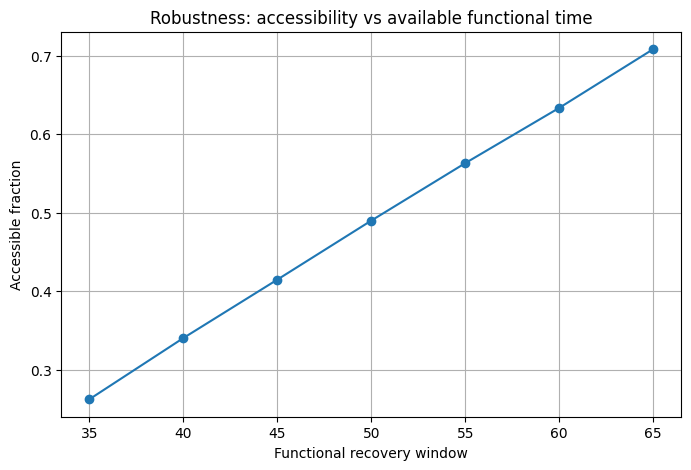

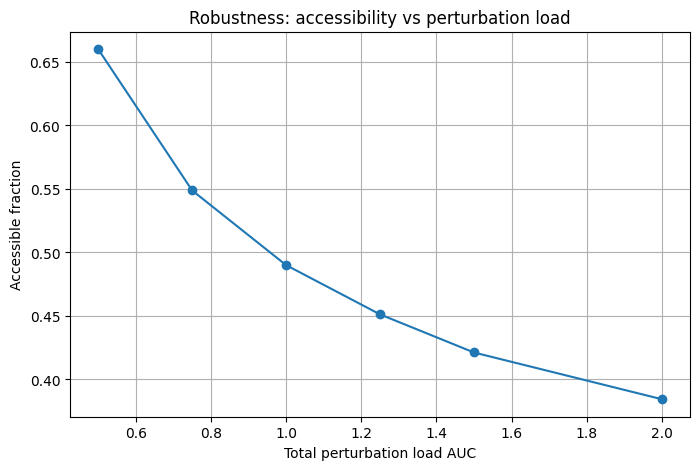

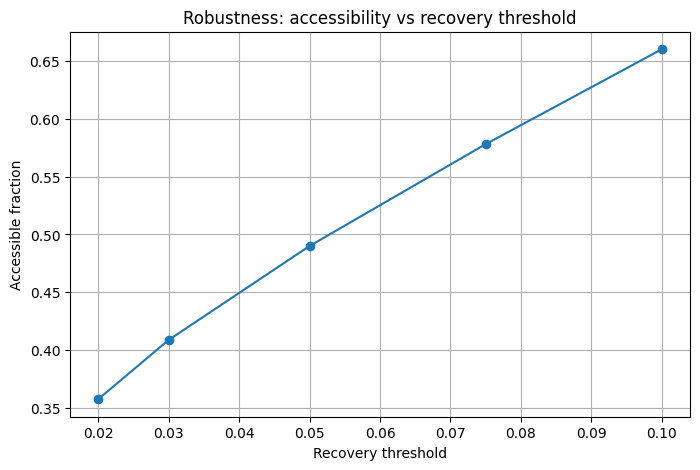

In [11]:
# ============================================================
# 8C. ROBUSTNESS FIGURES
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(window_robustness_df["t_window"], window_robustness_df["accessible_fraction"], marker="o")
plt.xlabel("Functional recovery window")
plt.ylabel("Accessible fraction")
plt.title("Robustness: accessibility vs available functional time")
plt.grid(True)
plt.savefig(f"{PROJECT_PATH}/figures/robustness_accessibility_vs_window.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(auc_robustness_df["auc"], auc_robustness_df["accessible_fraction"], marker="o")
plt.xlabel("Total perturbation load AUC")
plt.ylabel("Accessible fraction")
plt.title("Robustness: accessibility vs perturbation load")
plt.grid(True)
plt.savefig(f"{PROJECT_PATH}/figures/robustness_accessibility_vs_auc.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(threshold_robustness_df["recovery_threshold"], threshold_robustness_df["accessible_fraction"], marker="o")
plt.xlabel("Recovery threshold")
plt.ylabel("Accessible fraction")
plt.title("Robustness: accessibility vs recovery threshold")
plt.grid(True)
plt.savefig(f"{PROJECT_PATH}/figures/robustness_accessibility_vs_threshold.png", dpi=300, bbox_inches="tight")
plt.show()

## Interpretation

The robustness tests assess whether temporal accessibility is sensitive to arbitrary parameter choices.

A robust result should show orderly changes under parameter variation, rather than irregular disappearance of the recoverability structure.

# 9. Sequential perturbations and history dependence

We next test whether recoverability depends only on the current perturbation or also on prior dynamical history.

Sequential perturbations allow partial unresolved recovery from earlier forcing to alter accessibility after subsequent events.

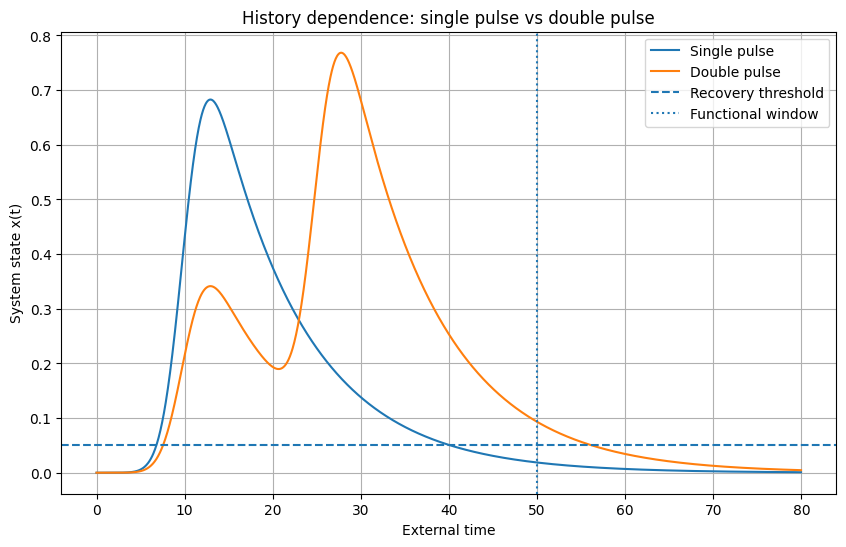

In [12]:
# ============================================================
# 9. HISTORY DEPENDENCE
# ============================================================

def double_gaussian_input(
    t,
    auc1=0.5,
    auc2=1.0,
    sigma1=2.0,
    sigma2=2.0,
    center1=10,
    center2=25
):
    u1 = gaussian_input(t, auc=auc1, sigma=sigma1, center=center1)
    u2 = gaussian_input(t, auc=auc2, sigma=sigma2, center=center2)
    return u1 + u2


def simulate_double_pulse(
    tau_r,
    sigma1=2.0,
    sigma2=2.0,
    auc1=0.5,
    auc2=1.0,
    center1=10,
    center2=25
):
    def system(t, x):
        u = double_gaussian_input(
            t,
            auc1=auc1,
            auc2=auc2,
            sigma1=sigma1,
            sigma2=sigma2,
            center1=center1,
            center2=center2
        )
        return [-x[0] / tau_r + u]

    sol = solve_ivp(
        system,
        t_span=(0, T_MAX),
        y0=[x0],
        t_eval=t_eval,
        rtol=1e-8,
        atol=1e-10
    )

    x = sol.y[0]
    u = double_gaussian_input(
        t_eval,
        auc1=auc1,
        auc2=auc2,
        sigma1=sigma1,
        sigma2=sigma2,
        center1=center1,
        center2=center2
    )

    return t_eval, x, u


# Single vs double pulse example
plt.figure(figsize=(10, 6))

t, x_single, u_single = simulate_trajectory(tau_r=10, sigma=2, auc=1.0)
plt.plot(t, x_single, label="Single pulse")

t, x_double, u_double = simulate_double_pulse(
    tau_r=10,
    sigma1=2,
    sigma2=2,
    auc1=0.5,
    auc2=1.0
)
plt.plot(t, x_double, label="Double pulse")

plt.axhline(RECOVERY_THRESHOLD, linestyle="--", label="Recovery threshold")
plt.axvline(T_WINDOW, linestyle=":", label="Functional window")
plt.xlabel("External time")
plt.ylabel("System state x(t)")
plt.title("History dependence: single pulse vs double pulse")
plt.legend()
plt.grid(True)
plt.savefig(f"{PROJECT_PATH}/figures/history_dependence_single_vs_double_pulse.png", dpi=300, bbox_inches="tight")
plt.show()

,auc1,gap,accessible_fraction,mean_functional_time,mean_x_max
0,0.00,8,0.40,-0.679268,0.673876
1,0.00,12,0.34,-2.494737,0.673876
2,0.00,16,0.30,-4.312857,0.673876
3,0.00,20,0.24,-6.134375,0.673876
4,0.00,25,0.16,-8.958621,0.673876
5,0.25,8,0.38,-0.458974,0.769046
6,0.25,12,0.34,-1.854167,0.745741
7,0.25,16,0.28,-4.122059,0.729257
8,0.25,20,0.24,-6.479688,0.717127
9,0.25,25,0.16,-9.134483,0.706057


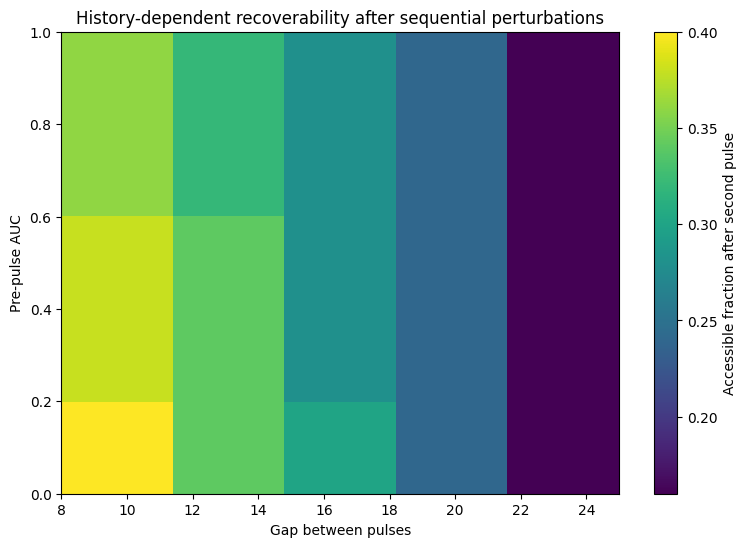

In [13]:
# ============================================================
# 9B. DOUBLE-PULSE SWEEP
# ============================================================

double_pulse_results = []

auc1_values = [0.0, 0.25, 0.5, 0.75, 1.0]
gap_values = [8, 12, 16, 20, 25]

for auc1 in auc1_values:
    for gap in gap_values:
        center1 = 10
        center2 = center1 + gap

        for tau_r in tau_r_values:
            t, x, u = simulate_double_pulse(
                tau_r=tau_r,
                sigma1=2.0,
                sigma2=2.0,
                auc1=auc1,
                auc2=1.0,
                center1=center1,
                center2=center2
            )

            metrics = compute_recovery_metrics(
                t,
                x,
                peak_time=center2,
                t_window=T_WINDOW,
                recovery_threshold=RECOVERY_THRESHOLD
            )

            double_pulse_results.append({
                "auc1": auc1,
                "auc2": 1.0,
                "gap": gap,
                "center2": center2,
                "tau_r": tau_r,
                "recovered": metrics["recovered"],
                "recovered_within_window": metrics["recovered_within_window"],
                "t_return": metrics["t_return"],
                "functional_time": metrics["functional_time"],
                "x_max": metrics["x_max"]
            })

double_pulse_df = pd.DataFrame(double_pulse_results)

double_summary = double_pulse_df.groupby(
    ["auc1", "gap"]
).agg(
    accessible_fraction=("recovered_within_window", "mean"),
    mean_functional_time=("functional_time", lambda x: np.nanmean(pd.Series(x).replace(-np.inf, np.nan))),
    mean_x_max=("x_max", "mean")
).reset_index()

pivot_double_accessibility = double_summary.pivot(
    index="auc1",
    columns="gap",
    values="accessible_fraction"
)

display(double_summary)

plt.figure(figsize=(9, 6))
plt.imshow(
    pivot_double_accessibility,
    origin="lower",
    aspect="auto",
    extent=[min(gap_values), max(gap_values), min(auc1_values), max(auc1_values)]
)

plt.colorbar(label="Accessible fraction after second pulse")
plt.xlabel("Gap between pulses")
plt.ylabel("Pre-pulse AUC")
plt.title("History-dependent recoverability after sequential perturbations")
plt.savefig(f"{PROJECT_PATH}/figures/history_dependent_recoverability_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## Interpretation

Sequential perturbations introduce effective history dependence without adding explicit memory terms.

The second perturbation is evaluated against the residual state left by the first perturbation, showing that functional time may depend on unresolved prior dynamics.

# 10. Stochastic robustness

Real systems are not perfectly deterministic.

We introduce stochastic fluctuations using an Euler–Maruyama formulation:

\[
x_{t+dt} = x_t + dt \left(-\frac{x_t}{\tau_r} + u(t)\right) + \eta \sqrt{dt} \xi_t
\]

where \(\eta\) is the noise strength.

The goal is to test whether the deterministic boundary persists as a probabilistic transition band.

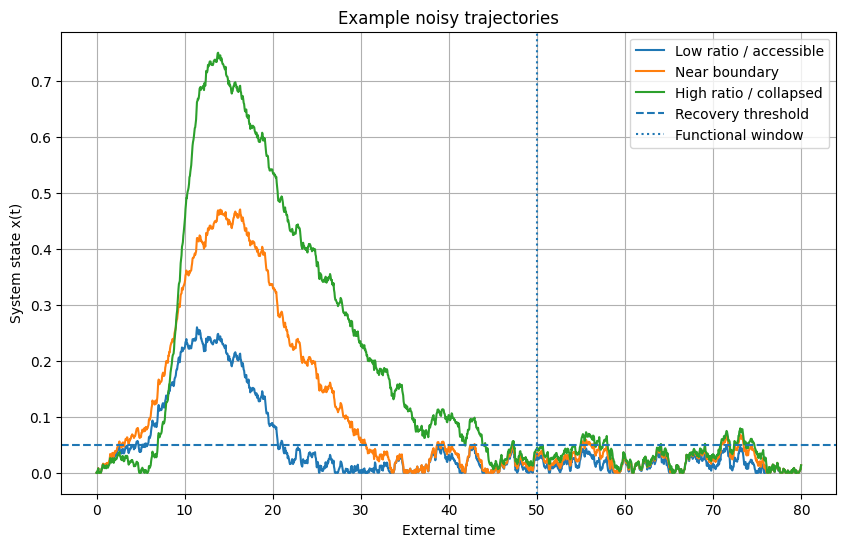

In [14]:
# ============================================================
# 10. STOCHASTIC ROBUSTNESS
# ============================================================

def simulate_noisy_trajectory(
    tau_r,
    sigma,
    auc=AUC,
    noise_strength=0.02,
    t_max=T_MAX,
    dt=DT,
    seed=None
):
    """
    Euler-Maruyama simulation:
    dx = (-x/tau_r + u(t)) dt + noise_strength dW
    """
    rng = np.random.default_rng(seed)

    t = np.arange(0, t_max, dt)
    x = np.zeros(len(t))
    u_values = gaussian_input(t, auc=auc, sigma=sigma)

    x[0] = x0

    for i in range(1, len(t)):
        drift = -x[i-1] / tau_r + u_values[i-1]
        noise = noise_strength * np.sqrt(dt) * rng.normal()
        x[i] = x[i-1] + drift * dt + noise

        # Floor prevents unrealistic negative overshoot below baseline
        if x[i] < 0:
            x[i] = 0

    return t, x, u_values


# Example noisy trajectories
noisy_cases = [
    {"label": "Low ratio / accessible", "sigma": 4.0, "tau_r": 3.0},
    {"label": "Near boundary", "sigma": 4.0, "tau_r": 8.0},
    {"label": "High ratio / collapsed", "sigma": 2.0, "tau_r": 15.0},
]

plt.figure(figsize=(10, 6))

for case in noisy_cases:
    t, x, u = simulate_noisy_trajectory(
        tau_r=case["tau_r"],
        sigma=case["sigma"],
        noise_strength=0.02,
        seed=42
    )
    plt.plot(t, x, label=case["label"])

plt.axhline(RECOVERY_THRESHOLD, linestyle="--", label="Recovery threshold")
plt.axvline(T_WINDOW, linestyle=":", label="Functional window")
plt.xlabel("External time")
plt.ylabel("System state x(t)")
plt.title("Example noisy trajectories")
plt.legend()
plt.grid(True)
plt.savefig(f"{PROJECT_PATH}/figures/noisy_trajectory_examples.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
# ============================================================
# 10B. STOCHASTIC SWEEP
# ============================================================

N_TRIALS = 30
NOISE_STRENGTH = 0.02

stochastic_results = []

for sigma in sigma_values:
    for tau_r in tau_r_values:
        for trial in range(N_TRIALS):
            t, x, u = simulate_noisy_trajectory(
                tau_r=tau_r,
                sigma=sigma,
                auc=AUC,
                noise_strength=NOISE_STRENGTH,
                seed=trial
            )

            metrics = compute_recovery_metrics(t, x)

            stochastic_results.append({
                "sigma": sigma,
                "tau_r": tau_r,
                "trial": trial,
                "noise_strength": NOISE_STRENGTH,
                "recovered": metrics["recovered"],
                "recovered_within_window": metrics["recovered_within_window"],
                "t_return": metrics["t_return"],
                "functional_time": metrics["functional_time"],
                "x_max": metrics["x_max"],
                "tau_sigma_ratio": tau_r / sigma,
                "sigma_tau_ratio": sigma / tau_r
            })

stochastic_df = pd.DataFrame(stochastic_results)

stochastic_summary = stochastic_df.copy()
stochastic_summary["functional_time_clean"] = stochastic_summary["functional_time"].replace(-np.inf, np.nan)

stochastic_summary = stochastic_summary.groupby(
    ["sigma", "tau_r"]
).agg(
    recovery_probability=("recovered_within_window", "mean"),
    mean_t_return=("t_return", "mean"),
    mean_functional_time=("functional_time_clean", "mean"),
    std_functional_time=("functional_time_clean", "std"),
    mean_x_max=("x_max", "mean"),
    tau_sigma_ratio=("tau_sigma_ratio", "mean")
).reset_index()

display(stochastic_summary.head())

,sigma,tau_r,recovery_probability,mean_t_return,mean_functional_time,std_functional_time,mean_x_max,tau_sigma_ratio
0,0.5,1.000000,1.0,13.140000,36.860000,0.273672,0.484674,2.000000
1,0.5,1.489796,1.0,14.456667,35.543333,0.500126,0.580627,2.979592
2,0.5,1.979592,1.0,15.698333,34.301667,0.549841,0.645704,3.959184
3,0.5,2.469388,1.0,17.278333,32.721667,1.082915,0.692762,4.938776
4,0.5,2.959184,1.0,18.450000,31.550000,1.203873,0.728848,5.918367


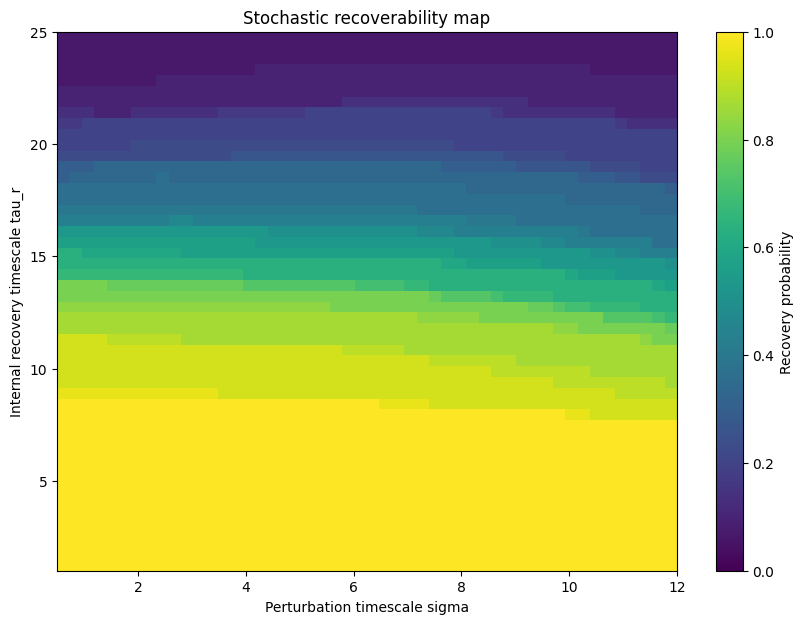

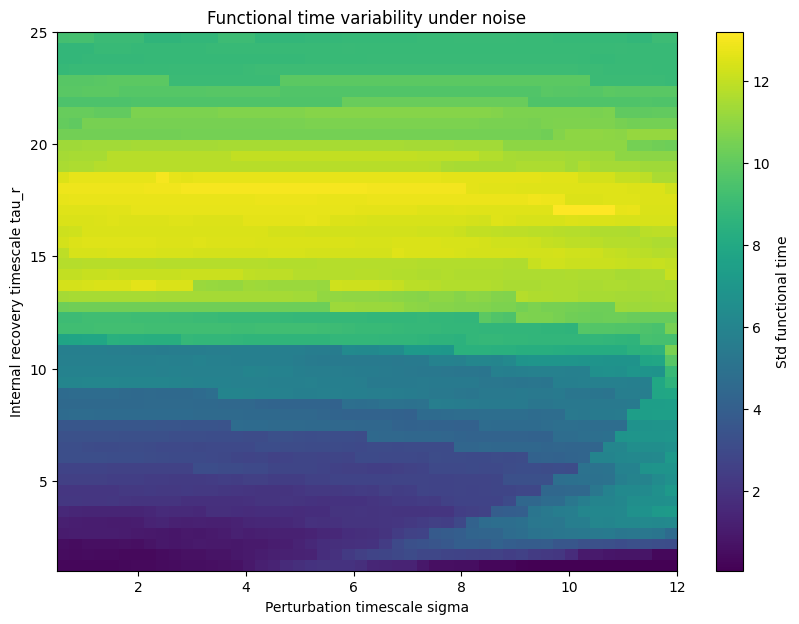

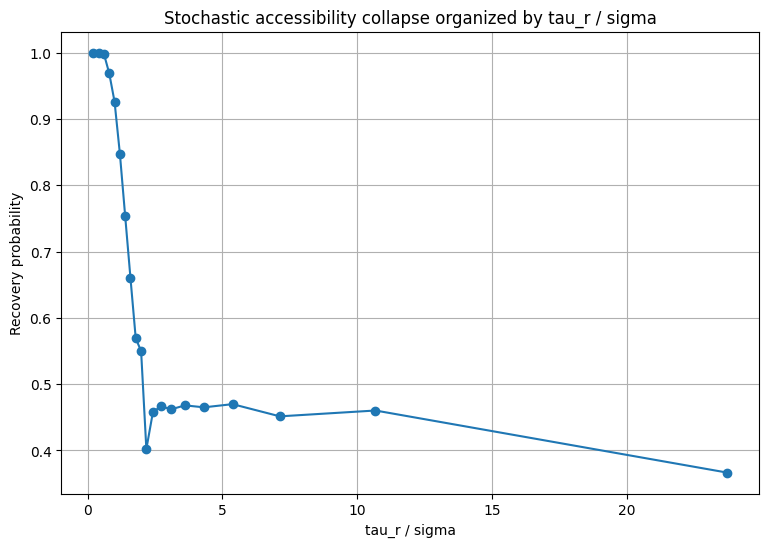

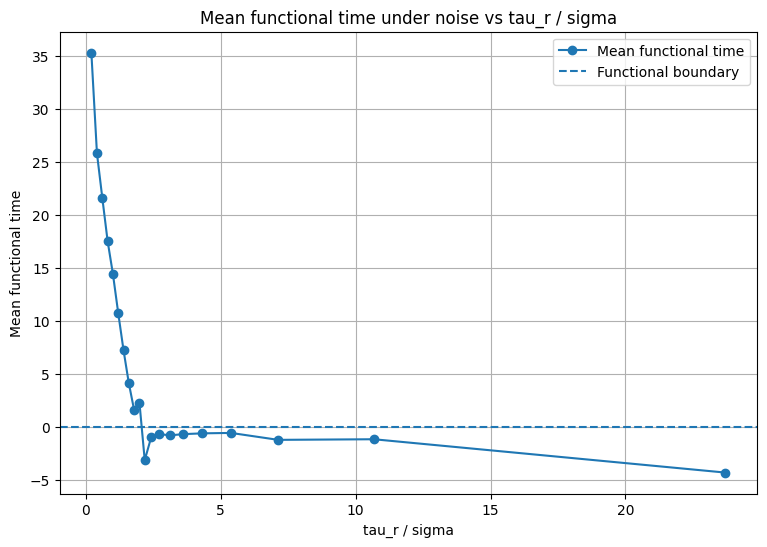

In [16]:
# ============================================================
# 10C. STOCHASTIC FIGURES AND RATIO
# ============================================================

pivot_recovery_probability = stochastic_summary.pivot(
    index="tau_r",
    columns="sigma",
    values="recovery_probability"
)

plt.figure(figsize=(10, 7))
plt.imshow(
    pivot_recovery_probability,
    origin="lower",
    aspect="auto",
    extent=[sigma_values.min(), sigma_values.max(), tau_r_values.min(), tau_r_values.max()],
    vmin=0,
    vmax=1
)

plt.colorbar(label="Recovery probability")
plt.xlabel("Perturbation timescale sigma")
plt.ylabel("Internal recovery timescale tau_r")
plt.title("Stochastic recoverability map")
plt.savefig(f"{PROJECT_PATH}/figures/stochastic_recoverability_probability_map.png", dpi=300, bbox_inches="tight")
plt.show()


pivot_functional_time_std = stochastic_summary.pivot(
    index="tau_r",
    columns="sigma",
    values="std_functional_time"
)

plt.figure(figsize=(10, 7))
plt.imshow(
    pivot_functional_time_std,
    origin="lower",
    aspect="auto",
    extent=[sigma_values.min(), sigma_values.max(), tau_r_values.min(), tau_r_values.max()]
)

plt.colorbar(label="Std functional time")
plt.xlabel("Perturbation timescale sigma")
plt.ylabel("Internal recovery timescale tau_r")
plt.title("Functional time variability under noise")
plt.savefig(f"{PROJECT_PATH}/figures/stochastic_functional_time_variability_map.png", dpi=300, bbox_inches="tight")
plt.show()


stochastic_ratio_df = stochastic_summary.dropna(subset=["tau_sigma_ratio"]).copy()

stochastic_ratio_df["ratio_bin"] = pd.qcut(
    stochastic_ratio_df["tau_sigma_ratio"],
    q=20,
    duplicates="drop"
)

stochastic_ratio_summary = stochastic_ratio_df.groupby("ratio_bin", observed=False).agg(
    mean_ratio=("tau_sigma_ratio", "mean"),
    recovery_probability=("recovery_probability", "mean"),
    mean_functional_time=("mean_functional_time", "mean"),
    std_functional_time=("std_functional_time", "mean")
).reset_index()

plt.figure(figsize=(9, 6))
plt.plot(
    stochastic_ratio_summary["mean_ratio"],
    stochastic_ratio_summary["recovery_probability"],
    marker="o"
)
plt.xlabel("tau_r / sigma")
plt.ylabel("Recovery probability")
plt.title("Stochastic accessibility collapse organized by tau_r / sigma")
plt.grid(True)
plt.savefig(f"{PROJECT_PATH}/figures/stochastic_recovery_probability_vs_ratio.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 6))
plt.plot(
    stochastic_ratio_summary["mean_ratio"],
    stochastic_ratio_summary["mean_functional_time"],
    marker="o",
    label="Mean functional time"
)
plt.axhline(0, linestyle="--", label="Functional boundary")
plt.xlabel("tau_r / sigma")
plt.ylabel("Mean functional time")
plt.title("Mean functional time under noise vs tau_r / sigma")
plt.legend()
plt.grid(True)
plt.savefig(f"{PROJECT_PATH}/figures/stochastic_functional_time_vs_ratio.png", dpi=300, bbox_inches="tight")
plt.show()

## Interpretation

Under stochastic forcing, the deterministic boundary broadens into a probabilistic transition region.

The persistence of a structured recoverability map under noise suggests that the observed boundary is not purely a deterministic artifact.

# 11. Numerical sensitivity

We test whether the main result depends on numerical choices such as:

- simulation time step `DT`
- total simulation length `T_MAX`
- sweep grid resolution

This protects against the possibility that the boundary is only a discretization artifact.

,label,dt,t_max,grid_n,accessible_fraction,mean_functional_time
0,baseline,0.050,80,50,0.490000,1.956612
1,smaller_dt,0.025,80,50,0.490000,1.969367
2,larger_dt,0.100,80,50,0.490000,1.945300
3,shorter_tmax,0.050,60,50,0.490000,11.905921
4,longer_tmax,0.050,100,50,0.490000,-0.838600
5,coarser_grid,0.050,80,30,0.485556,2.672503
6,finer_grid,0.050,80,70,0.489796,1.712486


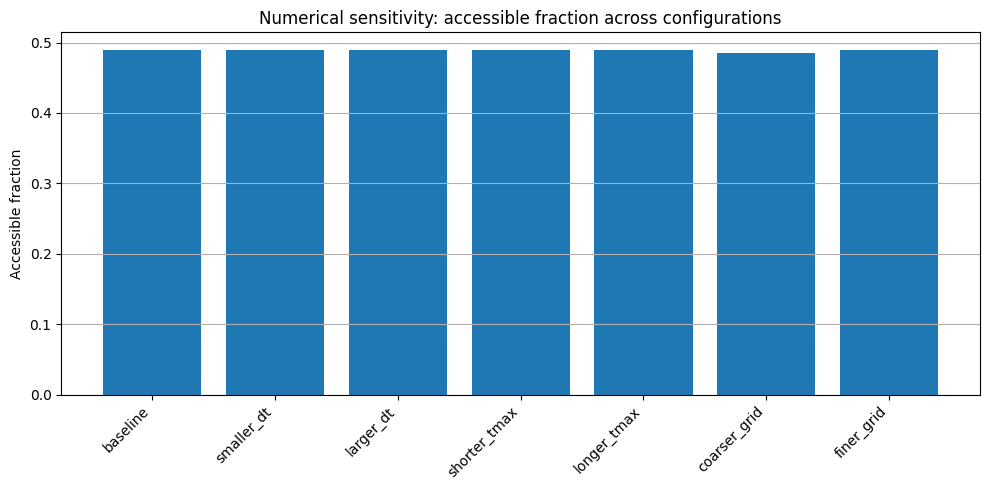

In [17]:
# ============================================================
# 11. NUMERICAL SENSITIVITY
# ============================================================

sensitivity_configs = [
    {"label": "baseline", "dt": 0.05, "t_max": 80, "grid_n": 50},
    {"label": "smaller_dt", "dt": 0.025, "t_max": 80, "grid_n": 50},
    {"label": "larger_dt", "dt": 0.10, "t_max": 80, "grid_n": 50},
    {"label": "shorter_tmax", "dt": 0.05, "t_max": 60, "grid_n": 50},
    {"label": "longer_tmax", "dt": 0.05, "t_max": 100, "grid_n": 50},
    {"label": "coarser_grid", "dt": 0.05, "t_max": 80, "grid_n": 30},
    {"label": "finer_grid", "dt": 0.05, "t_max": 80, "grid_n": 70},
]

sensitivity_results = []

for cfg in sensitivity_configs:
    local_sigma_values = np.linspace(0.5, 12, cfg["grid_n"])
    local_tau_r_values = np.linspace(1, 25, cfg["grid_n"])

    temp_df = run_functional_time_sweep(
        auc=AUC,
        t_window=T_WINDOW,
        recovery_threshold=RECOVERY_THRESHOLD,
        sigma_values=local_sigma_values,
        tau_r_values=local_tau_r_values,
        t_max=cfg["t_max"],
        dt=cfg["dt"]
    )

    accessible_fraction = temp_df["recovered_within_window"].mean()
    mean_functional_time = np.nanmean(temp_df["functional_time"].replace(-np.inf, np.nan))

    sensitivity_results.append({
        "label": cfg["label"],
        "dt": cfg["dt"],
        "t_max": cfg["t_max"],
        "grid_n": cfg["grid_n"],
        "accessible_fraction": accessible_fraction,
        "mean_functional_time": mean_functional_time
    })

sensitivity_df = pd.DataFrame(sensitivity_results)

display(sensitivity_df)

plt.figure(figsize=(10, 5))
plt.bar(sensitivity_df["label"], sensitivity_df["accessible_fraction"])
plt.ylabel("Accessible fraction")
plt.title("Numerical sensitivity: accessible fraction across configurations")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(f"{PROJECT_PATH}/figures/numerical_sensitivity_accessible_fraction.png", dpi=300, bbox_inches="tight")
plt.show()

## Interpretation

Numerical sensitivity tests assess whether the observed accessibility boundary remains stable under reasonable changes in computational resolution and simulation horizon.

The exact numerical values may shift, but the qualitative recoverability structure should persist.

# 12. Final summary and export

This section saves all core tables, writes summary files, and creates a ZIP archive of the reproducibility package.

In [18]:
# ============================================================
# 12. SAVE TABLES
# ============================================================

tables_to_save = {
    "functional_time_erc_results.csv": df,
    "functional_time_erc_results_enriched.csv": df,
    "critical_recoverability_boundary.csv": boundary_df,
    "ratio_summary_tau_sigma.csv": ratio_summary,
    "ratio_correlations.csv": correlations_df,
    "robustness_window.csv": window_robustness_df,
    "robustness_auc.csv": auc_robustness_df,
    "robustness_threshold.csv": threshold_robustness_df,
    "double_pulse_full_results.csv": double_pulse_df,
    "double_pulse_summary.csv": double_summary,
    "stochastic_full_results.csv": stochastic_df,
    "stochastic_summary.csv": stochastic_summary,
    "stochastic_ratio_summary.csv": stochastic_ratio_summary,
    "numerical_sensitivity.csv": sensitivity_df,
}

for filename, table in tables_to_save.items():
    path = f"{PROJECT_PATH}/tables/{filename}"
    table.to_csv(path, index=False)

print("Tables saved.")

Tables saved.


In [19]:
# ============================================================
# 12B. FINAL SUMMARY FILES
# ============================================================

accessible_fraction = df["recovered_within_window"].mean()
mean_functional_time = np.nanmean(df["functional_time"].replace(-np.inf, np.nan))

summary_text = f"""
Functional Time and Recoverability Window — Minimal ERC Model

Core hypothesis
---------------
Functional time may collapse before state-space collapse.

Main observations
-----------------
1. A recoverability boundary emerges in (sigma, tau_r) space.
2. Functional accessibility depends on the relation between recovery and perturbation timescales.
3. The ratio tau_r / sigma organizes the accessibility transition.
4. Increasing available recovery window increases accessible fraction.
5. Increasing perturbation load reduces accessible fraction.
6. The boundary persists under changes in recovery threshold.
7. Sequential perturbations show history-dependent recoverability.
8. Under stochastic perturbations, deterministic boundaries become probabilistic transition bands.
9. Functional-time variability increases under stochastic forcing.
10. Numerical sensitivity tests support that the qualitative result is not a simple discretization artifact.

Statistics
----------
Baseline accessible fraction: {accessible_fraction:.4f}
Baseline mean functional time: {mean_functional_time:.4f}

Interpretation
--------------
The results suggest that operational recoverability depends not only on the existence of states or trajectories,
but on whether the system can resolve perturbations within an available functional temporal window.

This supports a minimal ERC framing:
recoverability can degrade before the underlying dynamical state space disappears.

Limitations
-----------
This is a minimal exploratory model.
It should not be interpreted as evidence of universal dynamics or direct biological mechanism.
Its value is to isolate a falsifiable distinction between structural admissibility and functional temporal accessibility.
"""

with open(f"{PROJECT_PATH}/README_summary.txt", "w") as f:
    f.write(summary_text)


parameter_text = f"""
Parameter table

AUC = {AUC}
T_MAX = {T_MAX}
DT = {DT}
T_WINDOW = {T_WINDOW}
RECOVERY_THRESHOLD = {RECOVERY_THRESHOLD}
PERTURBATION_CENTER = {PERTURBATION_CENTER}

sigma range = {sigma_values.min()} to {sigma_values.max()}
tau_r range = {tau_r_values.min()} to {tau_r_values.max()}

Stochastic noise strength = {NOISE_STRENGTH}
Stochastic trials per point = {N_TRIALS}
"""

with open(f"{PROJECT_PATH}/parameter_table.txt", "w") as f:
    f.write(parameter_text)

print("Summary files saved.")

Summary files saved.


In [20]:
# ============================================================
# 12C. VERIFY FILE TREE AND CREATE ZIP
# ============================================================

print("Saved file tree:")
for root, dirs, files in os.walk(PROJECT_PATH):
    level = root.replace(PROJECT_PATH, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}{os.path.basename(root)}/")

    subindent = ' ' * (4 * (level + 1))
    for f in files:
        print(f"{subindent}{f}")

zip_path = shutil.make_archive(
    PROJECT_PATH,
    "zip",
    PROJECT_PATH
)

print("\nZIP created:")
print(zip_path)

Saved file tree:
functional_time_erc_model/
    parameter_table.txt
    README_summary.txt
    tables/
        ratio_correlations.csv
        robustness_threshold.csv
        double_pulse_summary.csv
        stochastic_ratio_summary.csv
        ratio_summary_tau_sigma.csv
        stochastic_summary.csv
        critical_recoverability_boundary.csv
        functional_time_erc_results_enriched.csv
        functional_time_erc_results.csv
        robustness_window.csv
        stochastic_full_results.csv
        double_pulse_full_results.csv
        robustness_auc.csv
        numerical_sensitivity.csv
    figures/
        functional_time_vs_tau_sigma_ratio_binned.png
        functional_time_landscape.png
        stochastic_recoverability_probability_map.png
        example_deterministic_trajectories.png
        stochastic_functional_time_vs_ratio.png
        robustness_accessibility_vs_threshold.png
        history_dependent_recoverability_heatmap.png
        history_dependence_single_vs_dou

# Final interpretation

This notebook supports a minimal operational interpretation of ERC:

> A system may retain its underlying state-space structure while losing the ability to recover within the available functional time window.

The strongest outputs are:

1. deterministic recoverability boundary  
2. functional time landscape  
3. temporal accessibility ratio \(\tau_r / \sigma\)  
4. history-dependent recoverability  
5. stochastic probabilistic boundary  
6. numerical sensitivity check  

The model remains exploratory, but it provides a reproducible computational basis for a short technical PDF or preprint-style note.

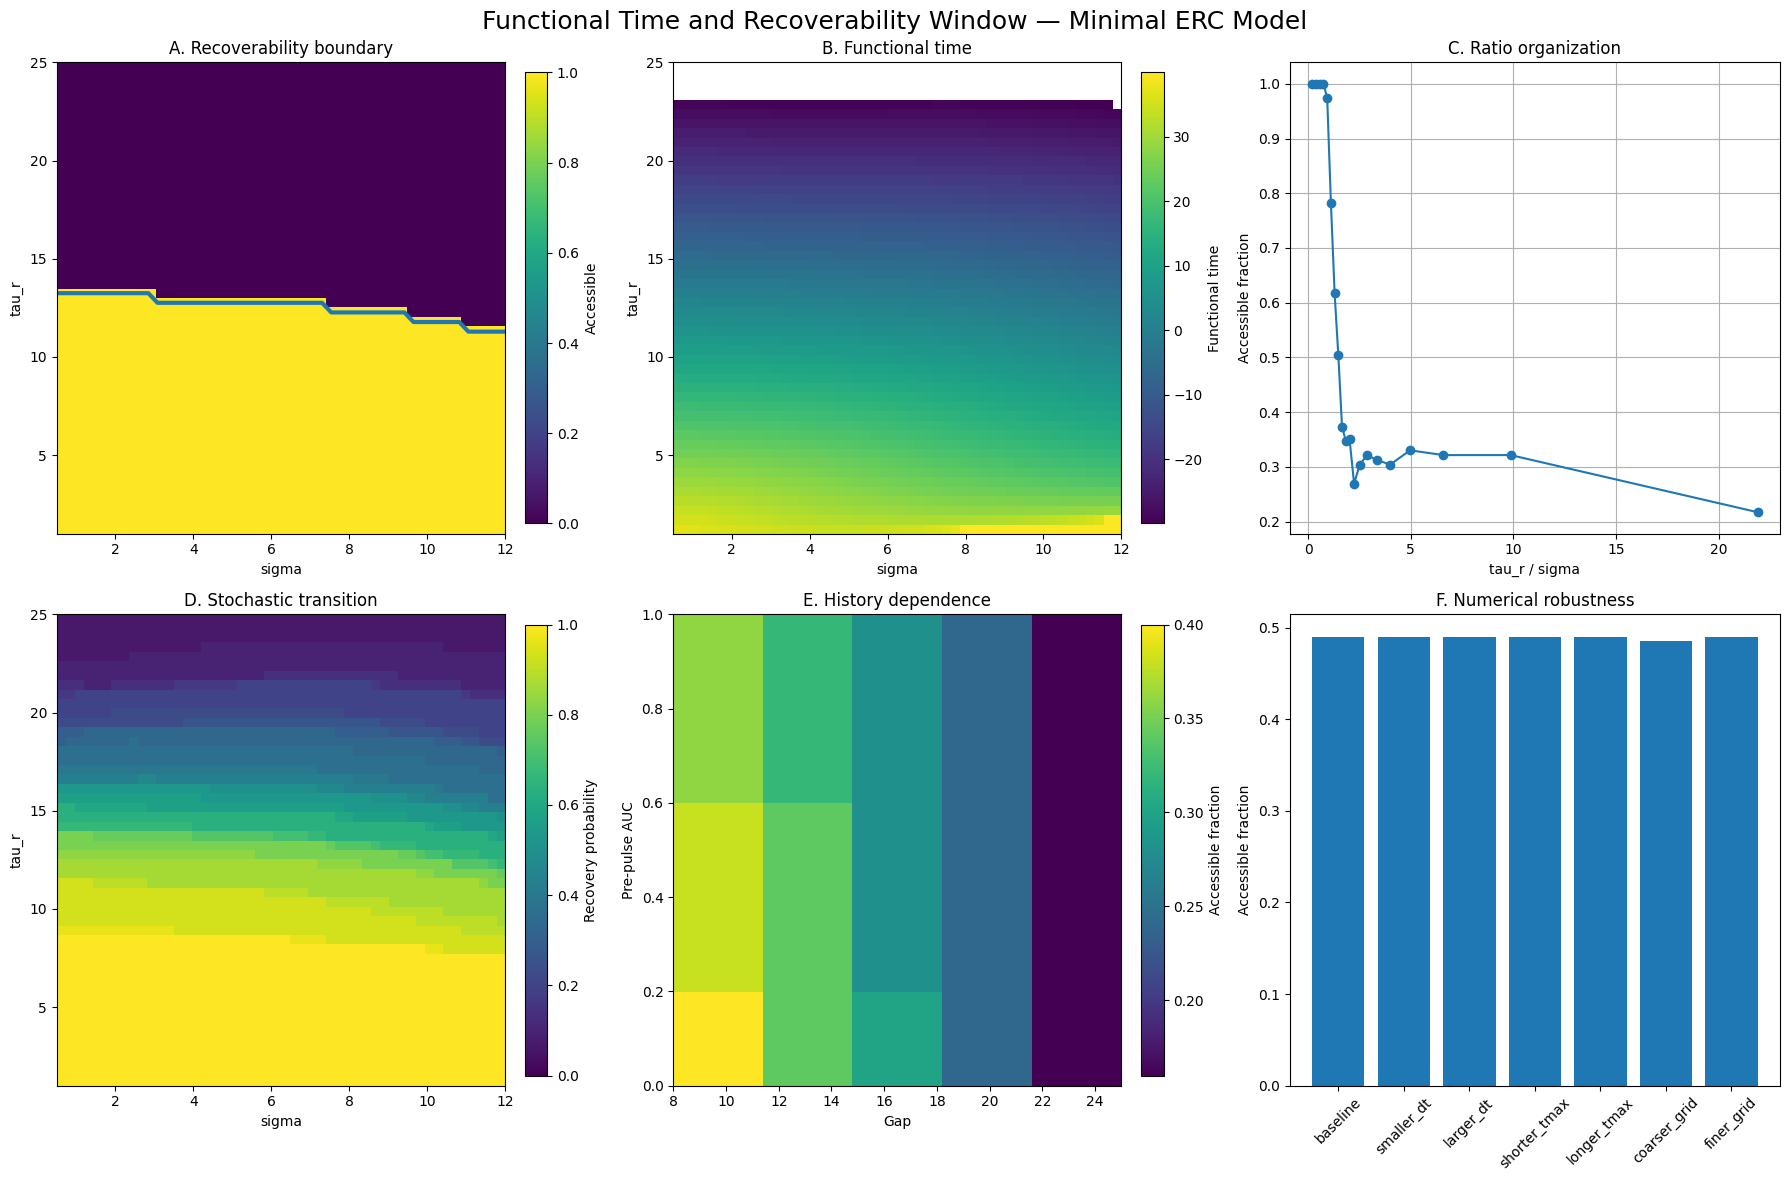

Final multipanel figure saved.


In [21]:
# ============================================================
# FINAL MULTIPANEL FIGURE
# Functional Time and Recoverability Window — ERC Model
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 12)
)

# ============================================================
# PANEL A — Recoverability boundary
# ============================================================

ax = axes[0, 0]

im1 = ax.imshow(
    pivot_recovery,
    origin="lower",
    aspect="auto",
    extent=[
        sigma_values.min(),
        sigma_values.max(),
        tau_r_values.min(),
        tau_r_values.max()
    ]
)

ax.plot(
    boundary_df["sigma"],
    boundary_df["tau_r_critical"],
    linewidth=3
)

ax.set_title("A. Recoverability boundary")

ax.set_xlabel("sigma")
ax.set_ylabel("tau_r")

fig.colorbar(
    im1,
    ax=ax,
    fraction=0.046,
    pad=0.04,
    label="Accessible"
)

# ============================================================
# PANEL B — Functional time landscape
# ============================================================

ax = axes[0, 1]

im2 = ax.imshow(
    pivot_functional_time,
    origin="lower",
    aspect="auto",
    extent=[
        sigma_values.min(),
        sigma_values.max(),
        tau_r_values.min(),
        tau_r_values.max()
    ]
)

ax.set_title("B. Functional time")

ax.set_xlabel("sigma")
ax.set_ylabel("tau_r")

fig.colorbar(
    im2,
    ax=ax,
    fraction=0.046,
    pad=0.04,
    label="Functional time"
)

# ============================================================
# PANEL C — Ratio organization
# ============================================================

ax = axes[0, 2]

ax.plot(
    ratio_summary["mean_ratio"],
    ratio_summary["accessible_fraction"],
    marker="o"
)

ax.set_title("C. Ratio organization")

ax.set_xlabel("tau_r / sigma")
ax.set_ylabel("Accessible fraction")

ax.grid(True)

# ============================================================
# PANEL D — Stochastic recoverability
# ============================================================

ax = axes[1, 0]

im4 = ax.imshow(
    pivot_recovery_probability,
    origin="lower",
    aspect="auto",
    extent=[
        sigma_values.min(),
        sigma_values.max(),
        tau_r_values.min(),
        tau_r_values.max()
    ],
    vmin=0,
    vmax=1
)

ax.set_title("D. Stochastic transition")

ax.set_xlabel("sigma")
ax.set_ylabel("tau_r")

fig.colorbar(
    im4,
    ax=ax,
    fraction=0.046,
    pad=0.04,
    label="Recovery probability"
)

# ============================================================
# PANEL E — History dependence
# ============================================================

ax = axes[1, 1]

im5 = ax.imshow(
    pivot_double_accessibility,
    origin="lower",
    aspect="auto",
    extent=[
        min(gap_values),
        max(gap_values),
        min(auc1_values),
        max(auc1_values)
    ]
)

ax.set_title("E. History dependence")

ax.set_xlabel("Gap")
ax.set_ylabel("Pre-pulse AUC")

fig.colorbar(
    im5,
    ax=ax,
    fraction=0.046,
    pad=0.04,
    label="Accessible fraction"
)

# ============================================================
# PANEL F — Numerical robustness
# ============================================================

ax = axes[1, 2]

ax.bar(
    sensitivity_df["label"],
    sensitivity_df["accessible_fraction"]
)

ax.set_title("F. Numerical robustness")

ax.set_ylabel("Accessible fraction")

ax.tick_params(axis='x', rotation=45)

# ============================================================
# GLOBAL TITLE
# ============================================================

fig.suptitle(
    "Functional Time and Recoverability Window — Minimal ERC Model",
    fontsize=18
)

plt.tight_layout()

# ============================================================
# SAVE FIGURE
# ============================================================

plt.savefig(
    f"{PROJECT_PATH}/figures/final_multipanel_figure.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Final multipanel figure saved.")